# Exploratory Data Analysis of NSW Electricity Demand

## Section 1 - Introduction

This notebook performs exploratory data analysis (EDA) on electricity demand in New South Wales (NSW). The analysis investigates the relationships between electricity demand, temperature, and forecast demand. In addition, machine learning techniques will later be applied to generate demand forecasts and compare them with the forecasts produced by the existing forecasting system.

## Section 2 - Data Loading

We load three datasets:

• Total electricity demand  
• Temperature observations  
• Forecast electricity demand  

These datasets will later be merged using the DATETIME field.

In [6]:
!git clone https://github.com/laukamkit/capstone_project_GroupA.git

Cloning into 'capstone_project_GroupA'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 83 (delta 17), reused 12 (delta 12), pack-reused 57 (from 2)
Receiving objects: 100% (83/83), 197.08 MiB | 26.54 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [7]:
!ls /content/capstone_project_GroupA/data/NSW

forecastdemand_nsw.csv.zip.partaa  temperature_nsw.csv.zip
forecastdemand_nsw.csv.zip.partab  totaldemand_nsw.csv.zip


In [8]:
import os

repo_path = "/content/capstone_project_GroupA"
nsw_path = os.path.join(repo_path, "data", "NSW")

part_a = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip.partaa")
part_b = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip.partab")
forecast_zip = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip")

with open(forecast_zip, "wb") as outfile:
    for p in [part_a, part_b]:
        with open(p, "rb") as infile:
            outfile.write(infile.read())

print("Created:", forecast_zip)
print("Files:", os.listdir(nsw_path))

Created: /content/capstone_project_GroupA/data/NSW/forecastdemand_nsw.csv.zip
Files: ['forecastdemand_nsw.csv.zip.partaa', 'forecastdemand_nsw.csv.zip.partab', 'totaldemand_nsw.csv.zip', 'forecastdemand_nsw.csv.zip', 'temperature_nsw.csv.zip']


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_demand = pd.read_csv(
    os.path.join(nsw_path, "totaldemand_nsw.csv.zip")
)

df_temp = pd.read_csv(
    os.path.join(nsw_path, "temperature_nsw.csv.zip")
)

df_forecast = pd.read_csv(
    os.path.join(nsw_path, "forecastdemand_nsw.csv.zip")
)


         LOCATION         DATETIME  TEMPERATURE
0       Bankstown    1/1/2010 0:00         23.1
1       Bankstown    1/1/2010 0:01         23.1
2       Bankstown    1/1/2010 0:30         22.9
3       Bankstown    1/1/2010 0:50         22.7
4       Bankstown    1/1/2010 1:00         22.6
...           ...              ...          ...
220321  Bankstown  17/3/2021 23:00         19.1
220322  Bankstown  17/3/2021 23:20         19.0
220323  Bankstown  17/3/2021 23:30         18.8
220324  Bankstown  17/3/2021 23:34         18.8
220325  Bankstown   18/3/2021 0:00         18.6

[220326 rows x 3 columns]
               DATETIME  TOTALDEMAND REGIONID
0         1/1/2010 0:00      8038.00     NSW1
1         1/1/2010 0:30      7809.31     NSW1
2         1/1/2010 1:00      7483.69     NSW1
3         1/1/2010 1:30      7117.23     NSW1
4         1/1/2010 2:00      6812.03     NSW1
...                 ...          ...      ...
196508  17/3/2021 22:00      7419.77     NSW1
196509  17/3/2021 22:30      

## Section 3 - Dataset Overview

Before performing analysis, we inspect the size and structure of each dataset.

In [35]:
print("Demand shape:", df_demand.shape)
print("Demand columns:", df_demand.columns.tolist())
print("Temp shape:", df_temp.shape)
print("Temp columns:", df_temp.columns.tolist())
print("Forecast shape:", df_forecast.shape)
print("Forecast columns:", df_forecast.columns.tolist())

Demand shape: (196513, 3)
Demand columns: ['DATETIME', 'TOTALDEMAND', 'REGIONID']
Temp shape: (220326, 3)
Temp columns: ['LOCATION', 'DATETIME', 'TEMPERATURE']
Forecast shape: (10906019, 6)
Forecast columns: ['PREDISPATCHSEQNO', 'REGIONID', 'PERIODID', 'FORECASTDEMAND', 'LASTCHANGED', 'DATETIME']


In [37]:
print(df_temp["LOCATION"].unique())
print(df_demand["REGIONID"].unique())

['Bankstown']
['NSW1']


After examining the categorical variables using unique(), it is observed that the LOCATION field contains only one value, Bankstown, and the REGIONID field contains only one value, NSW1. Since both variables have only a single category, they do not introduce any variation into the dataset and therefore do not contribute useful information for analysis. As a result, these two fields are going to be excluded from the merged dataset.

## Section 4 - Data Preparation

The forecast dataset contains over 10 million rows.  
To simplify analysis, we aggregate forecast demand by DATETIME using the mean value.

The datasets are then merged using the DATETIME field.

In [11]:
# Convert all DATETIME columns to real datetime
df_demand["DATETIME"] = pd.to_datetime(df_demand["DATETIME"], dayfirst=True, errors="coerce")
df_temp["DATETIME"] = pd.to_datetime(df_temp["DATETIME"], dayfirst=True, errors="coerce")
df_forecast["DATETIME"] = pd.to_datetime(df_forecast["DATETIME"], dayfirst=True, errors="coerce")

# Drop rows where DATETIME failed to parse
df_demand = df_demand.dropna(subset=["DATETIME"])
df_temp = df_temp.dropna(subset=["DATETIME"])
df_forecast = df_forecast.dropna(subset=["DATETIME"])

# Sort DATETIME
df_demand = df_demand.sort_values("DATETIME")
df_temp = df_temp.sort_values("DATETIME")
df_forecast = df_forecast.sort_values("DATETIME")

# Finding mean group by "DATETIME"
df_forecast_small = (
    df_forecast
    .groupby("DATETIME", as_index=False)["FORECASTDEMAND"]
    .mean()
)

# Merge with temperature database and demand database
df_merge = (
    df_demand
    .merge(df_temp, on="DATETIME", how="inner")
    .merge(df_forecast_small, on="DATETIME", how="inner")
)

# examine structure of merged database
print(df_merge.shape)
df_merge.head()
df_merge.info()
df_merge.describe()

(76326, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76326 entries, 0 to 76325
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DATETIME        76326 non-null  datetime64[ns]
 1   TOTALDEMAND     76326 non-null  float64       
 2   REGIONID        76326 non-null  object        
 3   LOCATION        76326 non-null  object        
 4   TEMPERATURE     76326 non-null  float64       
 5   FORECASTDEMAND  76326 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 3.5+ MB


,DATETIME,TOTALDEMAND,TEMPERATURE,FORECASTDEMAND
count,76326,76326.000000,76326.000000,76326.000000
mean,2015-07-06 14:52:04.306265600,8115.676118,17.420536,8113.518156
min,2010-01-01 00:00:00,5221.130000,0.200000,5032.458857
25%,2012-10-04 15:07:30,7167.387500,13.400000,7151.542173
50%,2015-07-06 04:45:00,8065.160000,17.700000,8069.099390
75%,2018-04-08 11:22:30,8946.622500,21.400000,8956.944474
max,2021-03-03 23:30:00,14579.860000,44.700000,14601.171964
std,NaN,1294.152447,5.893544,1300.282551


## Section 5 - Visualization

###(5.1) Electricity Demand over Time

This plot visualises electricity demand across time to identify
long-term patterns and seasonal fluctuations.

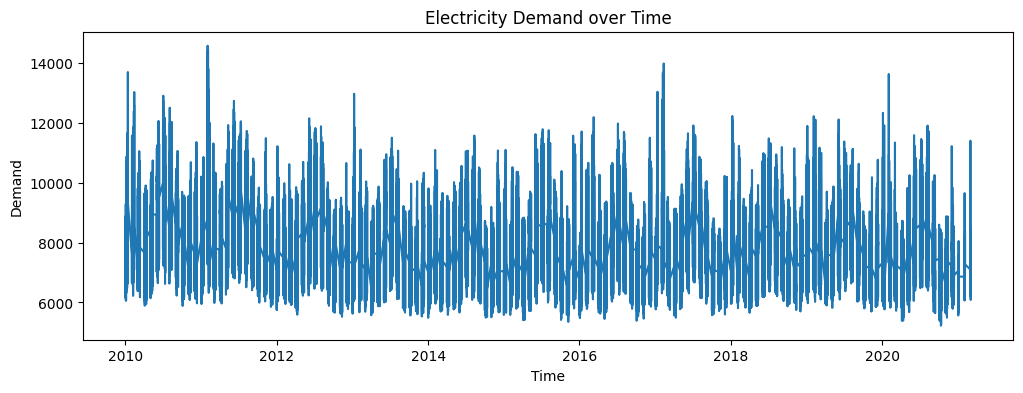

In [12]:
plt.figure(figsize=(12,4))

plt.plot(df_merge["DATETIME"], df_merge["TOTALDEMAND"])

plt.title("Electricity Demand over Time")
plt.xlabel("Time")
plt.ylabel("Demand")

plt.show()

Electricity demand exhibits strong temporal patterns. The demand fluctuates regularly over time, reflecting daily and seasonal consumption cycles. Peak demand values reach approximately 14,500 MW, while the lowest demand levels are around 5,500 MW.

### (5.2) Temperature vs Electricity Demand
This plot investigates the relationship between temperature and electricity demand.

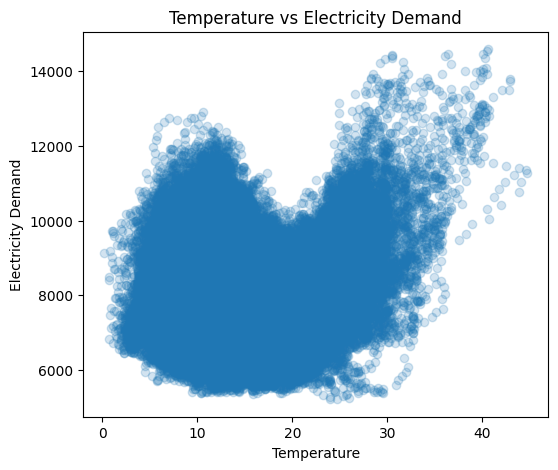

In [13]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_merge["TEMPERATURE"],
    df_merge["TOTALDEMAND"],
    alpha=0.2
)

plt.xlabel("Temperature")
plt.ylabel("Electricity Demand")

plt.title("Temperature vs Electricity Demand")

plt.show()

The relationship between temperature and electricity demand shows a clear U-shaped pattern. Demand tends to increase at both low and high temperatures, likely due to heating demand in colder conditions and air-conditioning usage during hotter periods. Demand appears lowest around moderate temperatures.

###(5.3) Forecast vs Actual Demand

This plot compares predicted electricity demand with actual demand.


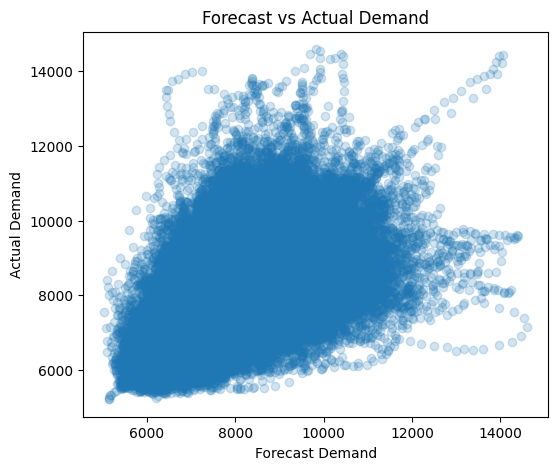

In [14]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_merge["FORECASTDEMAND"],
    df_merge["TOTALDEMAND"],
    alpha=0.2
)

plt.xlabel("Forecast Demand")
plt.ylabel("Actual Demand")

plt.title("Forecast vs Actual Demand")

plt.show()

The scatter plot between forecast demand and actual demand shows a strong positive correlation, indicating that the forecasting system captures overall demand trends well. However, some dispersion is observed, particularly at higher demand levels, suggesting forecasting errors during peak demand periods.

### (5.4) Correlation Analysis
The correlation matrix shows the relationships between demand, temperature and forecast demand.

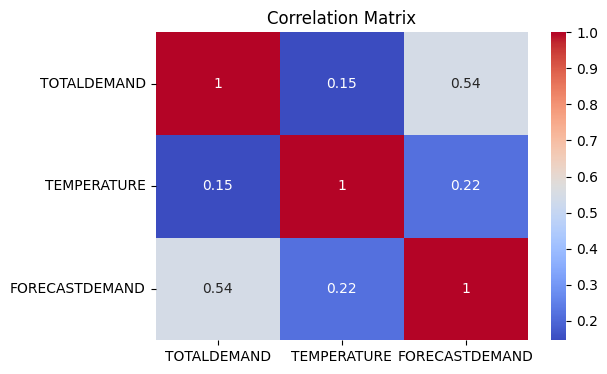

In [15]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df_merge[["TOTALDEMAND","TEMPERATURE","FORECASTDEMAND"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The scatter plot indicates a positive relationship between forecast demand and actual demand. This is supported by the correlation matrix, which shows a correlation coefficient of 0.54, confirming a moderate positive correlation between the two variables.

###(5.5) Monthly and Hourly Demand Analysis
The following plots present the average electricity demand by month and by hour of the day. These visualisations are used to investigate both seasonal variation and daily consumption patterns in electricity demand. The monthly analysis identifies periods of the year with relatively higher or lower demand, while the hourly analysis illustrates how electricity usage fluctuates throughout a typical day.

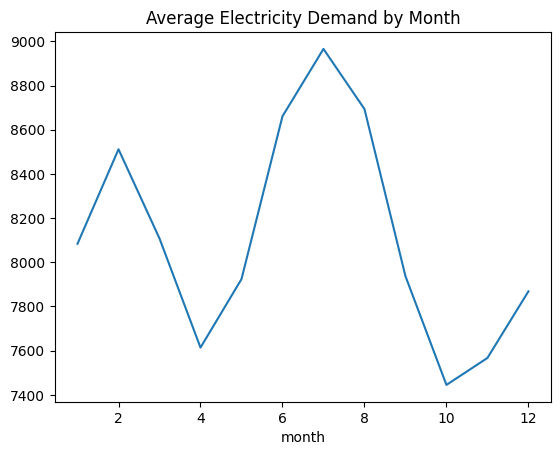

In [16]:
df_merge["month"] = df_merge["DATETIME"].dt.month

df_merge.groupby("month")["TOTALDEMAND"].mean().plot()

plt.title("Average Electricity Demand by Month")

plt.show()

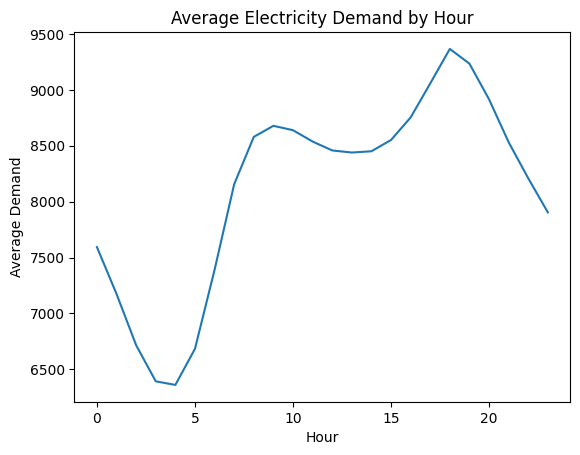

In [38]:
df_merge["hour"] = df_merge["DATETIME"].dt.hour

df_merge.groupby("hour")["TOTALDEMAND"].mean().plot()
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.show()

Monthly demand analysis reveals clear seasonal variation in electricity consumption. Average demand peaks during the winter months (June–August), which is consistent with increased heating usage during colder periods. In contrast, demand is lowest during milder months such as April and October when temperature conditions are more moderate.

In addition to seasonal patterns, the hourly demand profile shows clear daily variation. Electricity demand is lowest during the early morning hours (around 3–5 a.m.) when most households and businesses have minimal activity. Demand gradually increases during the daytime and reaches its peak in the evening (around 6–7 p.m.), which likely reflects higher household electricity usage after people return home from work.

## Section 5.6 - Additional EDA for Machine Learning

### (5.6.1) Distribution of Total Demand
This plot visualizes the distribution of the TOTALDEMAND to understand its statistical properties.

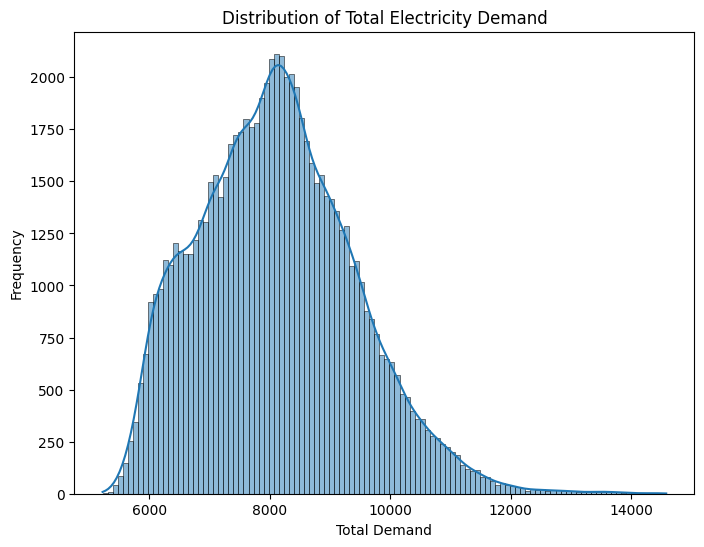

In [39]:
plt.figure(figsize=(8, 6))
sns.histplot(df_merge["TOTALDEMAND"], kde=True)
plt.title("Distribution of Total Electricity Demand")
plt.xlabel("Total Demand")
plt.ylabel("Frequency")
plt.show()

The distribution of total electricity demand appears to be approximately normal, slightly skewed to the right, indicating more instances of moderate demand and fewer instances of very high demand.

### (5.6.2) Outlier Detection for Demand and Temperature
Box plots are used to visualize the spread of TOTALDEMAND and TEMPERATURE and identify potential outliers.

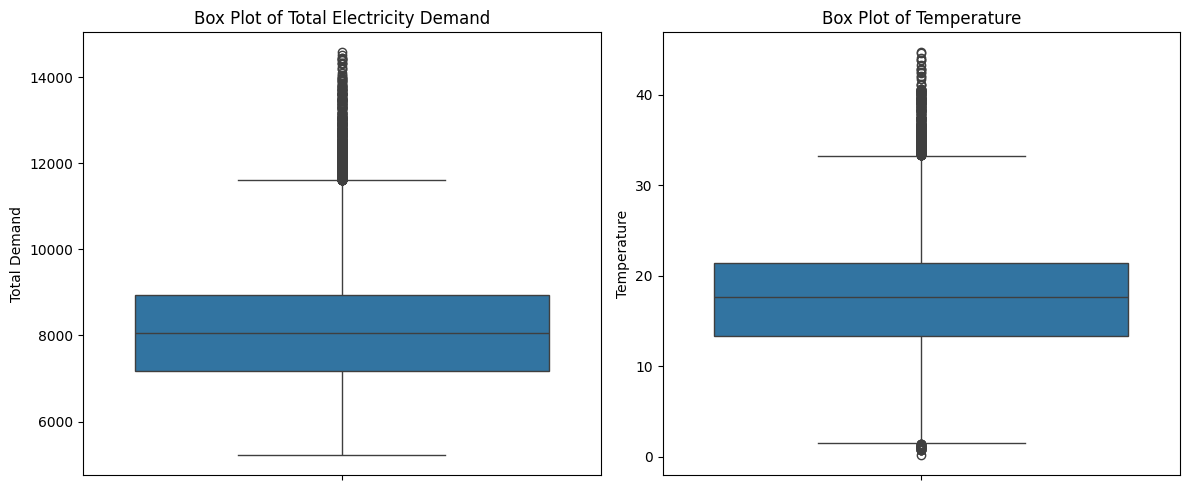

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_merge["TOTALDEMAND"])
plt.title("Box Plot of Total Electricity Demand")
plt.ylabel("Total Demand")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_merge["TEMPERATURE"])
plt.title("Box Plot of Temperature")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

The box plots show some potential outliers in both TOTALDEMAND and TEMPERATURE, particularly at the higher ends. These outliers could represent extreme events (e.g., heatwaves, cold snaps leading to very high demand) or data anomalies that might need further investigation or specific handling during model training.

## Section 6 - Summary

Exploratory data analysis reveals several important characteristics of the electricity demand dataset. The total electricity demand exhibits an approximately normal distribution, slightly skewed to the right, and includes some outliers, especially at higher values, as well as in temperature data. Electricity demand shows clear temporal patterns, including both seasonal variation across months and daily variation across hours. Temperature plays an important role in influencing electricity demand, with demand increasing during periods of extreme cold or high temperatures due to heating and cooling usage.

Furthermore, forecast demand shows a moderate positive correlation with actual demand, indicating that the forecasting system captures overall demand trends reasonably well, despite some observed variability.

These comprehensive findings provide a robust foundation for developing and refining predictive models for electricity demand, by highlighting key features, potential data challenges, and temporal structures.